# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("/content/unit2_ppt5_country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [3]:
# TODO 1: choropleth of total_gdp


# TODO 2: choropleth of gdpPercap


# TODO 3: top 5 countries by each -- print both lists
top_total = None
top_rate = None
print("Top 5 by total GDP:\n", top_total)
print("\nTop 5 by GDP per capita:\n", top_rate)

Top 5 by total GDP:
 None

Top 5 by GDP per capita:
 None


In [2]:
fig_total_gdp = px.choropleth(gap_latest,
                              locations="iso_alpha",
                              color="total_gdp",
                              hover_name="country",
                              color_continuous_scale=px.colors.sequential.Plasma,
                              title="Choropleth of Total GDP (2007)")
fig_total_gdp.show()

fig_gdp_per_cap = px.choropleth(gap_latest,
                                locations="iso_alpha",
                                color="gdpPercap",
                                hover_name="country",
                                color_continuous_scale=px.colors.sequential.Plasma,
                                title="Choropleth of GDP per Capita (2007)")
fig_gdp_per_cap.show()

top_total = gap_latest.sort_values(by='total_gdp', ascending=False).head(5)[['country', 'total_gdp']]
top_rate = gap_latest.sort_values(by='gdpPercap', ascending=False).head(5)[['country', 'gdpPercap']]

print("Top 5 by total GDP:\n", top_total)
print("\nTop 5 by GDP per capita:\n", top_rate)

Top 5 by total GDP:
            country     total_gdp
134  United States  1.293446e+13
24           China  6.539501e+12
66           Japan  4.035135e+12
58           India  2.722925e+12
47         Germany  2.650871e+12

Top 5 by GDP per capita:
            country    gdpPercap
95          Norway  49357.19017
71          Kuwait  47306.98978
113      Singapore  47143.17964
134  United States  42951.65309
62         Ireland  40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

_Your answer:_
Countries that appear in one top-5 list but not the other:
*   **Only in Top 5 by Total GDP:** China, Japan, India, Germany
*   **Only in Top 5 by GDP per Capita:** Norway, Kuwait, Singapore, Ireland

If I had to pick one map to show the director, I would pick the **Choropleth of GDP per Capita (`gdpPercap`)**.

I would choose the GDP per capita map because it aligns with the director's concern about not being misled by country size or raw counts. The `gdpPercap` map provides a per-person metric, which offers a more accurate representation of the economic well-being or productivity of a country, regardless of its population size or geographic area. The `total_gdp` map (a count-like metric) can be misleading as it heavily biases towards large, populous nations, potentially overstating their relative development compared to smaller, wealthier nations on a per-capita basis. This directly addresses the

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

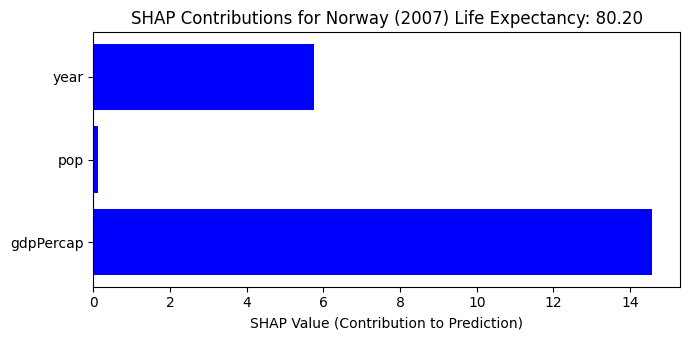

In [4]:
X_model = gapminder[["gdpPercap", "pop", "year"]]
y_model = gapminder["lifeExp"].values

# TODO 1: fit the model
rf = RandomForestRegressor(random_state=0)
rf.fit(X_model, y_model)

# TODO 2: SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# TODO 3: find Norway's row, plot its SHAP contributions
norway_2007_data = gapminder[(gapminder.country == 'Norway') & (gapminder.year == 2007)]
row_idx = norway_2007_data.index[0]

vals = shap_values[row_idx]
feature_names = X_model.columns

fig, ax = plt.subplots(figsize=(7, 3.5))

colors = ['blue' if v > 0 else 'red' for v in vals]
ax.barh(feature_names, vals, color=colors)
ax.set_title(f"SHAP Contributions for Norway (2007) Life Expectancy: {norway_2007_data.lifeExp.iloc[0]:.2f}")
ax.set_xlabel("SHAP Value (Contribution to Prediction)")
ax.axvline(0, color='grey', linestyle='--') # Add a vertical line at 0 for reference
plt.tight_layout()
plt.show()

**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_
The feature that contributed most **positively** to Norway's predicted life expectancy in 2007 was `gdpPercap`. All three features (`gdpPercap`, `pop`, and `year`) showed positive contributions for Norway's prediction.

This is **not** necessarily the same answer you would get from the model's GLOBAL feature importance alone. Global feature importance tells us the average contribution of each feature across all predictions in the dataset. Local SHAP values, on the other hand, explain the contribution of each feature to a *single, specific prediction* (in this case, Norway's life expectancy in 2007). A feature might be globally important but have a minimal or even negative impact on a particular instance, or vice-versa.

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

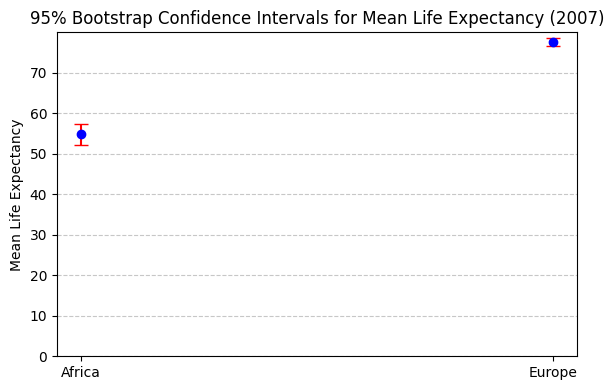

In [5]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    boot_means = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(np.mean(sample))

    overall_mean = np.mean(values)
    ci_low = np.percentile(boot_means, 2.5)
    ci_high = np.percentile(boot_means, 97.5)
    return (overall_mean, ci_low, ci_high)

# TODO 2: compute CIs for two continents of your choice
continent_a, continent_b = "Africa", "Europe"  # feel free to change these
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)

# TODO 3: plot both as error bars (mean +/- CI half-width) on one chart
means = [result_a[0], result_b[0]]
lower_errors = [result_a[0] - result_a[1], result_b[0] - result_b[1]]
upper_errors = [result_a[2] - result_a[0], result_b[2] - result_b[0]]

error_bars = np.array([lower_errors, upper_errors])

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar([continent_a, continent_b], means, yerr=error_bars, fmt='o', capsize=5, color='blue', ecolor='red')
ax.set_ylabel("Mean Life Expectancy")
ax.set_title("95% Bootstrap Confidence Intervals for Mean Life Expectancy (2007)")
ax.set_ylim(bottom=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_
Africa has a wider confidence interval for mean life expectancy (approx. 5.29) compared to Europe (approx. 2.08). This is primarily due to higher variation among countries (SD) in Africa's life expectancy (standard deviation of ~10.45 for Africa vs. ~2.70 for Europe). Although Europe has a smaller sample size (30 countries) than Africa (52 countries), which would tend to widen its CI, the significantly higher variability in Africa's life expectancy is the dominant factor causing its confidence interval to be much wider

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

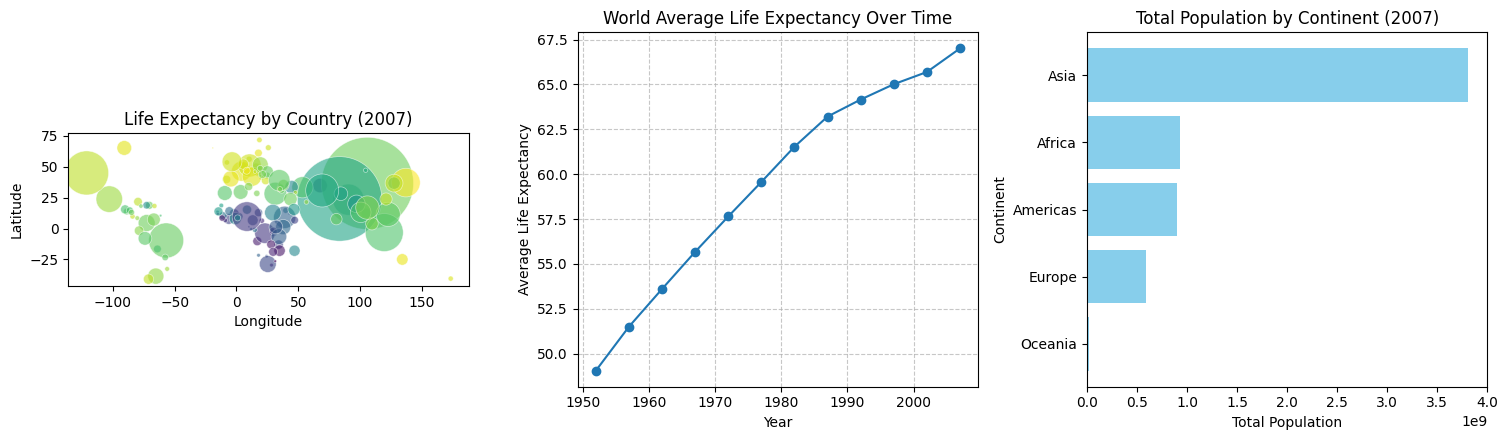

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# TODO 1: map-style scatter (axes[0])
axes[0].scatter(gap_latest.centroid_lon, gap_latest.centroid_lat,
                c=gap_latest.lifeExp, cmap='viridis', s=gap_latest['pop']/3e5, alpha=0.6,
                edgecolors='w', linewidths=0.5)
axes[0].set_title('Life Expectancy by Country (2007)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_aspect('equal')

# TODO 2: world trend line (axes[1])
world_avg_lifeexp = gapminder.groupby('year')['lifeExp'].mean().reset_index()
axes[1].plot(world_avg_lifeexp['year'], world_avg_lifeexp['lifeExp'], marker='o', linestyle='-')
axes[1].set_title('World Average Life Expectancy Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Life Expectancy')
axes[1].grid(True, linestyle='--', alpha=0.7)

# TODO 3: population by continent bar chart (axes[2])
pop_by_continent = gap_latest.groupby('continent')['pop'].sum().sort_values(ascending=False)
axes[2].barh(pop_by_continent.index, pop_by_continent.values, color='skyblue')
axes[2].set_title('Total Population by Continent (2007)')
axes[2].set_xlabel('Total Population')
axes[2].set_ylabel('Continent')
axes[2].invert_yaxis() # To show largest at the top

plt.tight_layout()
plt.show()

**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_
If the director could only keep ONE of your three panels for a 5-second morning glance, I would recommend keeping the 'World Average Life Expectancy Over Time' (Panel 2). This panel is best for answering questions about trends. A quick glance would immediately reveal the overall direction of global health, whether life expectancy is consistently rising, plateauing, or showing any unexpected dips. The other two panels, while informative, are more about static snapshots (Panel 1) or comparisons of current aggregates (Panel 3), which are less indicative of 'what's changing' at a glance compared to a time-series trend.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_
For all future geospatial reports, I recommend standardizing on rate-based map framings, such as GDP per capita, over count-based metrics like total GDP. This approach directly addresses the 'Greenland vs. India' concern by visually representing per-capita metrics, preventing larger geographical areas from disproportionately influencing perception. When a journalist asks 'why did the model predict THAT for Norway specifically,' we should always lead with local feature importance (e.g., SHAP values) because it provides specific, attributable contributions for that individual prediction, unlike global feature importance which only gives an average view. Finally, the world average life expectancy trend in our dashboard should never be shown as a bare point estimate; it represents an average of diverse data, and without confidence intervals, it falsely implies a level of certainty that doesn't exist, potentially misrepresenting the true global trend and its variability.